## 1.Load and inspect the data, plot few examples from different arrythmia types 

In [15]:
#import libraries needed
import numpy as np
import seaborn as sns
import glob
import matplotlib.pyplot as plt
import pandas as pd
from scipy import *
from os import path
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
sns.set()

(30992, 277)
(37442, 277)


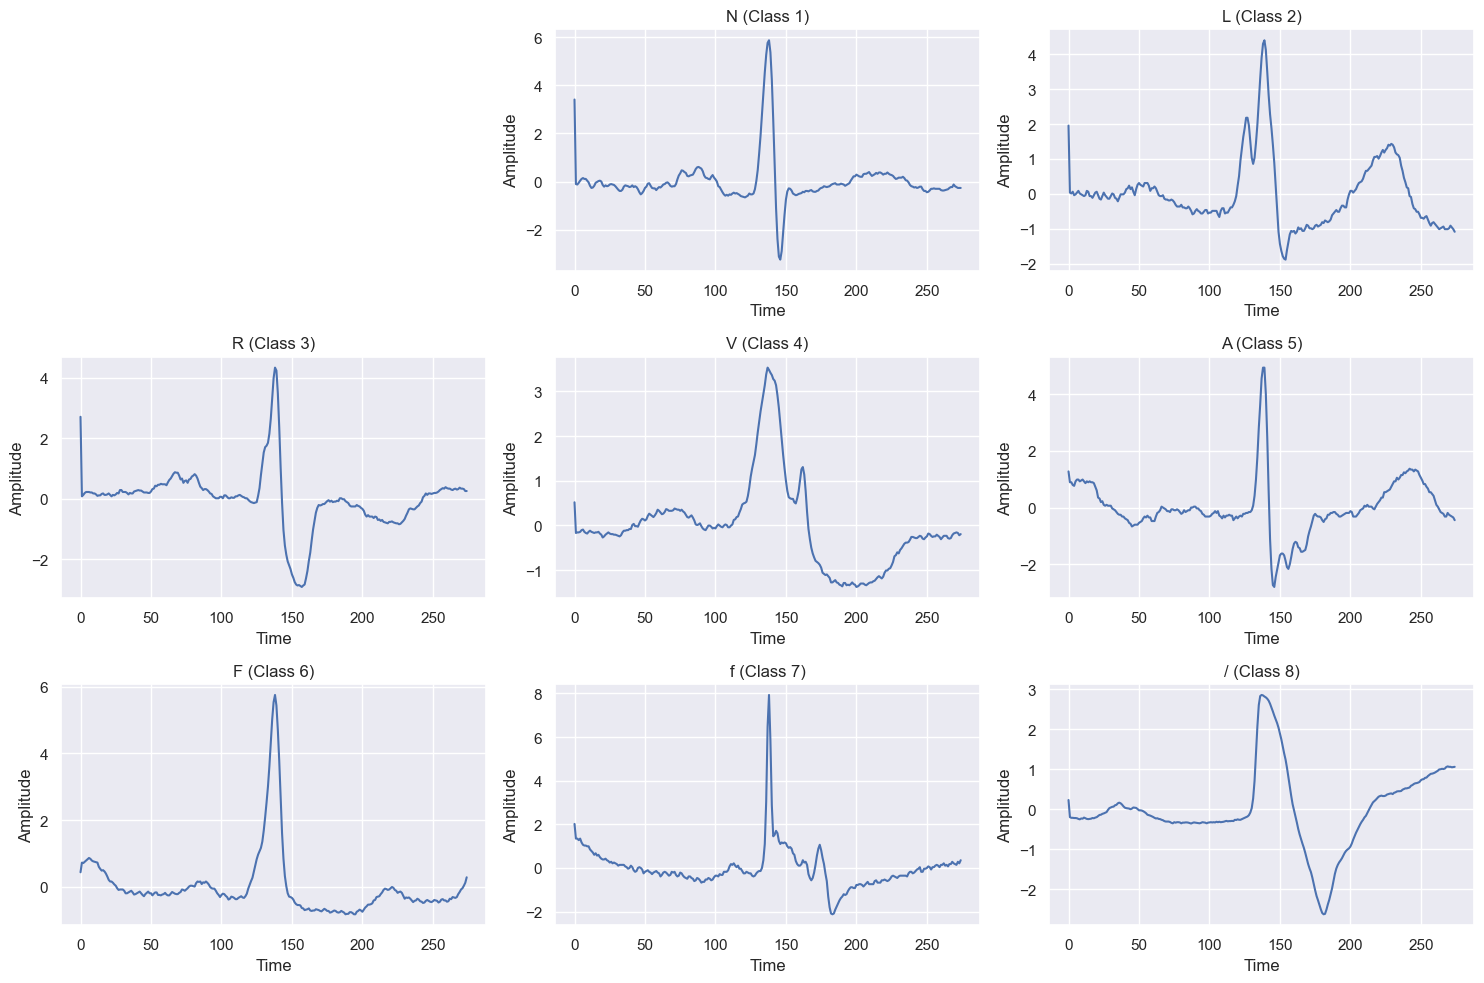

(30992, 275)
(37442, 275)


In [14]:
#load training and testing beats
train_csv = glob.glob('train_beats.csv')
test_csv = glob.glob('test_beats.csv')
train_beat = np.loadtxt(train_csv[0], delimiter=',')
test_beat = np.loadtxt(test_csv[0], delimiter=',')
print(train_beat.shape)
print(test_beat.shape)
#one-hot labels(using train data)
labels = train_beat[:, -2].astype(int)
train = train_beat[:, :-2]
test = test_beat[:,:-2]
#one-hot function
def one_hot_encode(labels, num_classes=9):
    return np.eye(num_classes)[labels]

labels_oh = one_hot_encode(labels)

#Visualization
class_names = ['O', 'N', 'L', 'R', 'V', 'A', 'F', 'f', '/']

def plot_examples_by_class(X, y, class_names):
    plt.figure(figsize=(15, 10))
    for class_id in range(9):
        idx = np.where(y == class_id)[0]
        if len(idx) == 0:
            continue  # 如果该类没有样本就跳过
        sample = X[idx[0]]
        plt.subplot(3, 3, class_id + 1)
        plt.plot(sample)
        plt.title(f"{class_names[class_id]} (Class {class_id})")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

plot_examples_by_class(train, labels, class_names)
print(train.shape)
print(test.shape)

## 2.Classification of ECG beats based on the holdout splitting method 

Accuracy: 0.9383312857219166
Precision: 0.7629080268021403
Recall: 0.9526727129987427
F1 Score: 0.8150335985713419


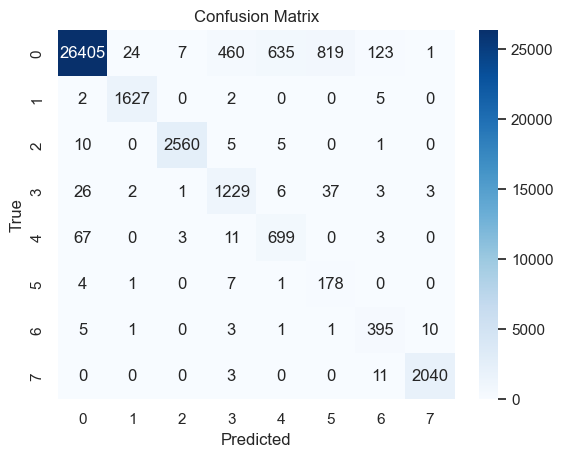

In [22]:
#load data
train_data = np.loadtxt('train_beats.csv', delimiter=',')
test_data = np.loadtxt('test_beats.csv', delimiter=',')

#training and testing sets
X_train = train_data[:, :-2]
y_train = train_data[:, -2].astype(int)
X_test = test_data[:, :-2]
y_test = test_data[:, -2].astype(int)
#Use SVC
model = SVC(kernel='rbf')
model.fit(X_train, y_train)
#predict
y_pred = model.predict(X_test)
#output results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test, y_pred, average='macro'))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()